# Module 3 - Assignment 1: Supervised Learning
### DS23 - Certified Data Scientist with Agentic AI
**Author:** Orarr2  
**Task chosen:** Option B - Telco Customer Churn (binary classification)

This notebook predicts customer churn from the public IBM Telco Customer Churn
dataset (7,043 rows, 21 columns). The work follows the six-station workflow
defined in the assignment brief.

All code and comments are in English.


---
## Part 0 - Frame the problem

**Business question (LTV framing).** Estimate the probability that each
subscriber will churn, so that the per-customer churn risk can feed a downstream
Customer Lifetime Value (LTV) model. LTV depends on both who is likely to leave
and who is likely to stay, so the model has to discriminate well across the
whole population, not just the high-risk tail.

**Target.** Binary label per customer: `churn = 1` if the dataset's `Churn`
column is "Yes", else `0`. Positive class rate = 26.5%.

**Primary metric: F1.** Both error types carry real business cost.
- **FN** (a churner the model misses) = lost subscriber and lost LTV; expensive.
- **FP** (a stable customer flagged as churn) = wasted retention offer; medium.

Accuracy is misleading at this base rate (a constant model scores 73.5%). F1
balances precision and recall directly. ROC-AUC is reported as a secondary
metric for the LTV ranking use case. I do not apply `class_weight='balanced'`
so probabilities stay closer to calibrated for the LTV consumer.


---
## Part 1 - Setup, data, honest split, baseline

In [1]:
# Setup: ensure every dependency is present, then print a version table.
import importlib
import subprocess
import sys

REQUIRED = [
    ("numpy",        "numpy",        "NumPy"),
    ("pandas",       "pandas",       "pandas"),
    ("matplotlib",   "matplotlib",   "Matplotlib"),
    ("seaborn",      "seaborn",      "Seaborn"),
    ("scipy",        "scipy",        "SciPy"),
    ("sklearn",      "scikit-learn", "scikit-learn"),
    ("xgboost",      "xgboost",      "XGBoost"),
    ("shap",         "shap",         "SHAP"),
    ("bidi",         "python-bidi",  "python-bidi"),
]

print("Checking dependencies ...")
for import_name, pip_name, _ in REQUIRED:
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"  installing {pip_name} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", pip_name]
        )
        importlib.invalidate_caches()
        importlib.import_module(import_name)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import chi2_contingency
import sklearn
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict,
                                     GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay)
from sklearn.exceptions import ConvergenceWarning
import xgboost as xgb_mod
from xgboost import XGBClassifier
import shap
import bidi

import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="shap")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

def _v(mod, attr="__version__"):
    return getattr(mod, attr, "?")

versions = [
    ("Python",       sys.version.split()[0]),
    ("NumPy",        np.__version__),
    ("pandas",       pd.__version__),
    ("Matplotlib",   matplotlib.__version__),
    ("Seaborn",      sns.__version__),
    ("SciPy",        scipy.__version__),
    ("scikit-learn", sklearn.__version__),
    ("XGBoost",      xgb_mod.__version__),
    ("SHAP",         shap.__version__),
    ("python-bidi",  _v(bidi)),
]
name_w = max(len(n) for n, _ in versions)
ver_w  = max(len(v) for _, v in versions)
print()
print(f"  {'library'.ljust(name_w)}   {'version'.ljust(ver_w)}")
print(f"  {'-' * name_w}   {'-' * ver_w}")
for name, ver in versions:
    print(f"  {name.ljust(name_w)}   {ver.ljust(ver_w)}")
print("\nAll dependencies ready.")

Checking dependencies ...

  library        version
  ------------   ------
  Python         3.13.9
  NumPy          2.3.5 
  pandas         2.3.3 
  Matplotlib     3.10.6
  Seaborn        0.13.2
  SciPy          1.16.3
  scikit-learn   1.7.2 
  XGBoost        3.2.0 
  SHAP           0.51.0
  python-bidi    ?     

All dependencies ready.



  library        version
  ------------   ------
  Python         3.9.2 
  NumPy          2.0.2 
  pandas         2.3.3 
  Matplotlib     3.9.4 
  Seaborn        0.13.2
  SciPy          1.13.1
  scikit-learn   1.6.1 
  XGBoost        2.1.4 
  SHAP           0.49.1
  python-bidi    ?     

All dependencies ready.


### Load and clean

The Telco CSV ships with `TotalCharges` as text; 11 rows have a blank. All 11
have `tenure = 0` (brand new customers who have not been billed yet) and all
are `Churn = No`. The semantically correct imputation is `0` - they have not
been charged anything.

In [2]:
def load_telco(path="WA_Fn-UseC_-Telco-Customer-Churn.csv"):
    """Load and clean the Telco churn CSV. Single source of truth."""
    df = pd.read_csv(path)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
    df["churn"] = (df["Churn"].str.strip().str.lower() == "yes").astype(int)
    return df

df = load_telco()
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.3f}")

Shape: (7043, 22)
Churn rate: 0.265


### Data card

A per-column summary in the style of a Kaggle dataset page: dtype, business
meaning, missing count, unique count, and either top categories or numeric
summary statistics. Rendered inline below and written to `DATA_CARD.md`.

Source: [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

In [3]:
from IPython.display import Markdown, display
from pathlib import Path

COLUMN_DESCRIPTIONS = {
    "customerID":       "Unique customer identifier.",
    "gender":           "Whether the customer is Male or Female.",
    "SeniorCitizen":    "1 if the customer is a senior citizen, else 0.",
    "Partner":          "Whether the customer has a partner (Yes / No).",
    "Dependents":       "Whether the customer has dependents (Yes / No).",
    "tenure":           "Number of months the customer has stayed with the company.",
    "PhoneService":     "Whether the customer has phone service (Yes / No).",
    "MultipleLines":    "Whether the customer has multiple lines (Yes / No / No phone service).",
    "InternetService":  "Customer's internet service provider (DSL / Fiber optic / No).",
    "OnlineSecurity":   "Online security add-on (Yes / No / No internet service).",
    "OnlineBackup":     "Online backup add-on (Yes / No / No internet service).",
    "DeviceProtection": "Device protection add-on (Yes / No / No internet service).",
    "TechSupport":      "Tech support add-on (Yes / No / No internet service).",
    "StreamingTV":      "Streaming TV add-on (Yes / No / No internet service).",
    "StreamingMovies":  "Streaming movies add-on (Yes / No / No internet service).",
    "Contract":         "Contract term (Month-to-month / One year / Two year).",
    "PaperlessBilling": "Whether the customer uses paperless billing (Yes / No).",
    "PaymentMethod":    "Payment method (Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic)).",
    "MonthlyCharges":   "Current monthly charge in USD.",
    "TotalCharges":     "Cumulative charges since signup in USD.",
    "Churn":            "TARGET: Yes if the customer churned in the last month, else No.",
    "churn":            "Numeric target derived from `Churn`: 1 if Yes, else 0.",
}

def _summary_for(col, s):
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 10:
        return (f"mean={s.mean():.2f}  std={s.std():.2f}  "
                f"min={s.min():.2f}  max={s.max():.2f}")
    vc = s.value_counts(dropna=False).head(3)
    total = len(s)
    return ", ".join(f"{k!s}: {v} ({v / total:.0%})" for k, v in vc.items())

def build_data_card(df, descriptions=COLUMN_DESCRIPTIONS):
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   int(s.isna().sum()),
            "n_unique":    int(s.nunique(dropna=True)),
            "top / stats": _summary_for(col, s),
            "description": descriptions.get(col, ""),
        })
    return pd.DataFrame(rows)

def _df_to_md(df):
    cols = list(df.columns)
    rows = df.astype(str).values.tolist()
    widths = [max(len(c), *(len(r[i]) for r in rows)) for i, c in enumerate(cols)]
    header = "| " + " | ".join(c.ljust(w) for c, w in zip(cols, widths)) + " |"
    sep    = "|"  + "|".join("-" * (w + 2) for w in widths) + "|"
    body   = "\n".join(
        "| " + " | ".join(r[i].ljust(widths[i]) for i in range(len(cols))) + " |"
        for r in rows
    )
    return f"{header}\n{sep}\n{body}"

def render_data_card(df, out_path="DATA_CARD.md"):
    card = build_data_card(df)
    header = (
        f"# Data Card - Telco Customer Churn\n\n"
        f"**Source:** [Kaggle: blastchar/telco-customer-churn]"
        f"(https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  \n"
        f"**Shape:** {df.shape[0]:,} rows x {df.shape[1]} columns  \n"
        f"**Target:** `churn` (positive class rate = {df['churn'].mean():.1%})  \n"
        f"**Snapshot type:** cross-sectional (no time column)\n\n"
        f"## Column reference\n\n"
    )
    body = _df_to_md(card)
    sample = f"\n\n## Sample rows\n\n{_df_to_md(df.head(5))}\n"
    Path(out_path).write_text(header + body + sample, encoding="utf-8")
    display(Markdown(f"**Shape:** {df.shape[0]:,} rows x {df.shape[1]} columns "
                     f"&nbsp;|&nbsp; **target rate:** {df['churn'].mean():.1%}"))
    display(card.style
            .set_properties(**{"text-align": "left"})
            .set_table_styles([{"selector": "th",
                                "props": [("text-align", "left")]}])
            .hide(axis="index"))
    print(f"\n[OK] Written: {out_path}")
    return card

_ = render_data_card(df)

**Shape:** 7,043 rows x 22 columns &nbsp;|&nbsp; **target rate:** 26.5%

column,dtype,n_missing,n_unique,top / stats,description
customerID,object,0,7043,"7590-VHVEG: 1 (0%), 3791-LGQCY: 1 (0%), 6008-NAIXK: 1 (0%)",Unique customer identifier.
gender,object,0,2,"Male: 3555 (50%), Female: 3488 (50%)",Whether the customer is Male or Female.
SeniorCitizen,int64,0,2,"0: 5901 (84%), 1: 1142 (16%)","1 if the customer is a senior citizen, else 0."
Partner,object,0,2,"No: 3641 (52%), Yes: 3402 (48%)",Whether the customer has a partner (Yes / No).
Dependents,object,0,2,"No: 4933 (70%), Yes: 2110 (30%)",Whether the customer has dependents (Yes / No).
tenure,int64,0,73,mean=32.37 std=24.56 min=0.00 max=72.00,Number of months the customer has stayed with the company.
PhoneService,object,0,2,"Yes: 6361 (90%), No: 682 (10%)",Whether the customer has phone service (Yes / No).
MultipleLines,object,0,3,"No: 3390 (48%), Yes: 2971 (42%), No phone service: 682 (10%)",Whether the customer has multiple lines (Yes / No / No phone service).
InternetService,object,0,3,"Fiber optic: 3096 (44%), DSL: 2421 (34%), No: 1526 (22%)",Customer's internet service provider (DSL / Fiber optic / No).
OnlineSecurity,object,0,3,"No: 3498 (50%), Yes: 2019 (29%), No internet service: 1526 (22%)",Online security add-on (Yes / No / No internet service).



[OK] Written: DATA_CARD.md


In [4]:
# Sanity check
print("Explicit NaN per column:")
nans = df.isna().sum()
print(nans[nans > 0] if nans.sum() else "  none")
print(f"\nDuplicated customerIDs: {df.duplicated(subset=['customerID']).sum()}")
print(f"Duplicated full rows:     {df.duplicated().sum()}")

Explicit NaN per column:
  none

Duplicated customerIDs: 0
Duplicated full rows:     0


### Exploratory Data Analysis

In [5]:
# Identify column types
cat_cols = [c for c in df.columns
            if pd.api.types.is_string_dtype(df[c]) and c not in ("customerID", "Churn")]
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
print(f"Categorical ({len(cat_cols)}):", cat_cols)
print(f"Numeric ({len(num_cols)}):", num_cols)

Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']


#### Light - distributions and target relationships

In [6]:
print("Numeric features - mean by class:")
print(df.groupby("churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2))

Numeric features - mean by class:
       tenure  MonthlyCharges  TotalCharges
churn                                      
0       37.57           61.27       2549.91
1       17.98           74.44       1531.80


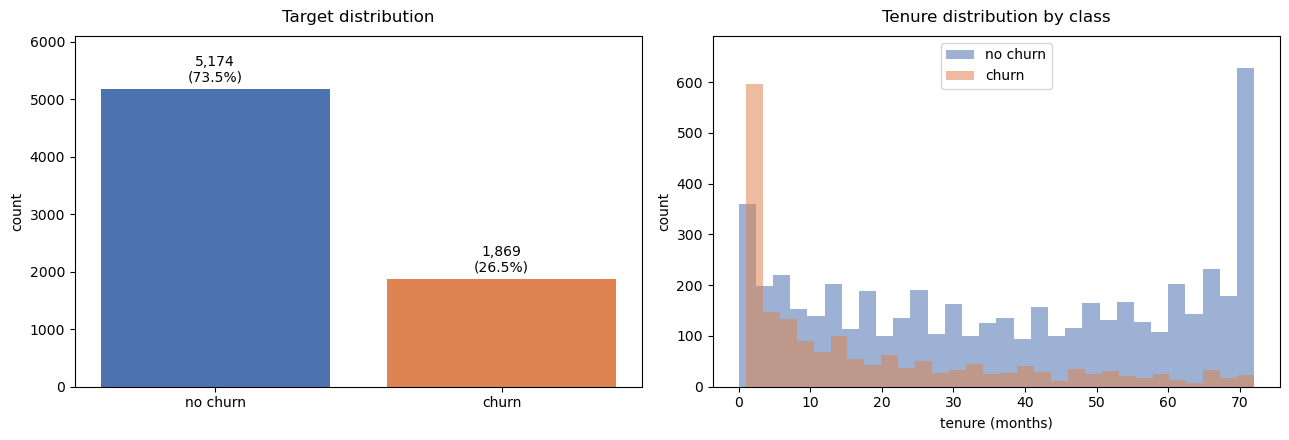

In [7]:
# Target balance + tenure distribution by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
counts = df["churn"].value_counts().sort_index()
bars = ax.bar(["no churn", "churn"], counts.values,
              color=["#4c72b0", "#dd8452"])
for rect, v in zip(bars, counts.values):
    ax.text(rect.get_x() + rect.get_width() / 2,
            v + counts.max() * 0.015,
            f"{v:,}\n({v / len(df):.1%})",
            ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title("Target distribution", pad=10)
ax.set_ylabel("count")
ax.grid(False)

ax = axes[1]
max_h = 0
for v, label, color in [(0, "no churn", "#4c72b0"), (1, "churn", "#dd8452")]:
    counts_h, _, _ = ax.hist(df.loc[df["churn"] == v, "tenure"],
                              bins=30, alpha=0.55, label=label, color=color)
    max_h = max(max_h, counts_h.max())
ax.set_ylim(0, max_h * 1.10)
ax.set_xlabel("tenure (months)")
ax.set_ylabel("count")
ax.set_title("Tenure distribution by class", pad=10)
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

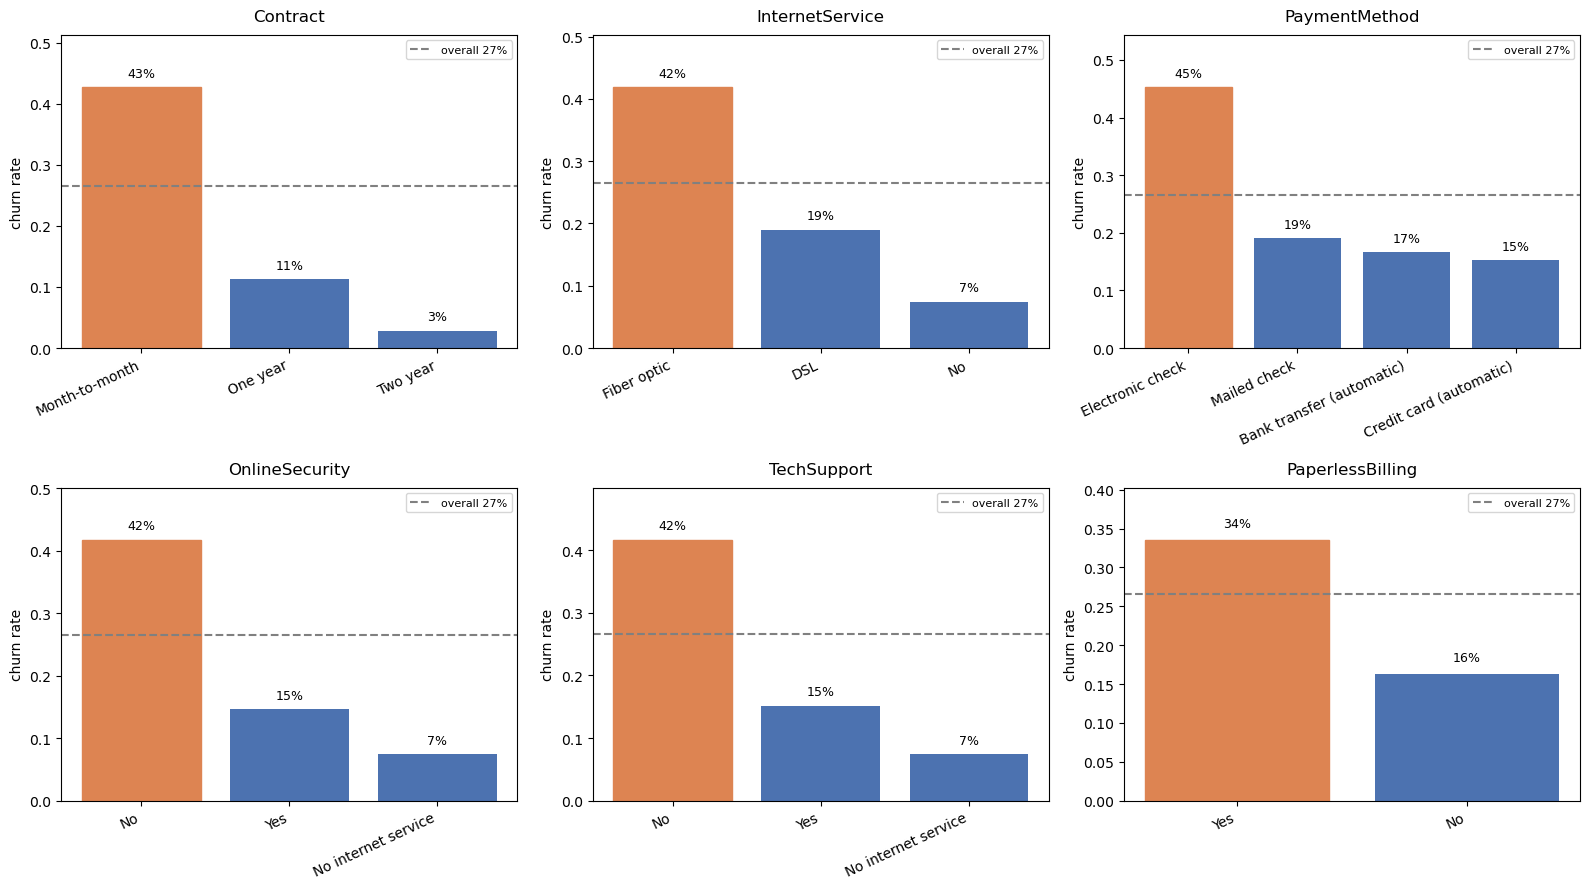

In [8]:
# Churn rate by category for the strongest predictors
key_cats = ["Contract", "InternetService", "PaymentMethod",
            "OnlineSecurity", "TechSupport", "PaperlessBilling"]
overall = df["churn"].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), key_cats):
    g = df.groupby(col, observed=True)["churn"].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(g)), g.values, color="#4c72b0")
    bars[0].set_color("#dd8452")
    for rect, v in zip(bars, g.values):
        ax.text(rect.get_x() + rect.get_width() / 2,
                v + 0.012,
                f"{v:.0%}",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels([str(x) for x in g.index], rotation=25, ha="right")
    ax.axhline(overall, color="grey", linestyle="--",
               label=f"overall {overall:.0%}")
    ax.set_ylim(0, max(g.values.max(), overall) * 1.20)
    ax.set_title(col, pad=10)
    ax.set_ylabel("churn rate")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(False)

plt.tight_layout()
plt.show()

#### Plus - multicollinearity diagnostics

Two known risks for the linear model:
1. `tenure` and `TotalCharges` are correlated (TotalCharges is roughly
   tenure x MonthlyCharges over time).
2. Service columns include "No internet service", which appears iff
   `InternetService = "No"` - a structural dependency.

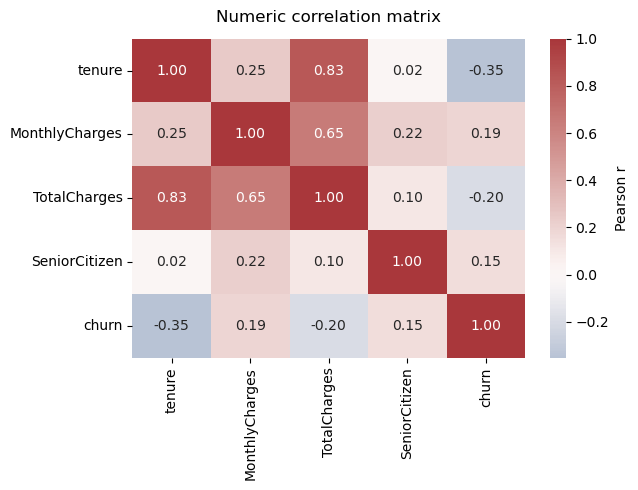

In [9]:
# Numeric correlation matrix
corr = df[num_cols + ["churn"]].corr().round(3)
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f",
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Numeric correlation matrix", pad=12)
ax.grid(False)
plt.tight_layout()
plt.show()

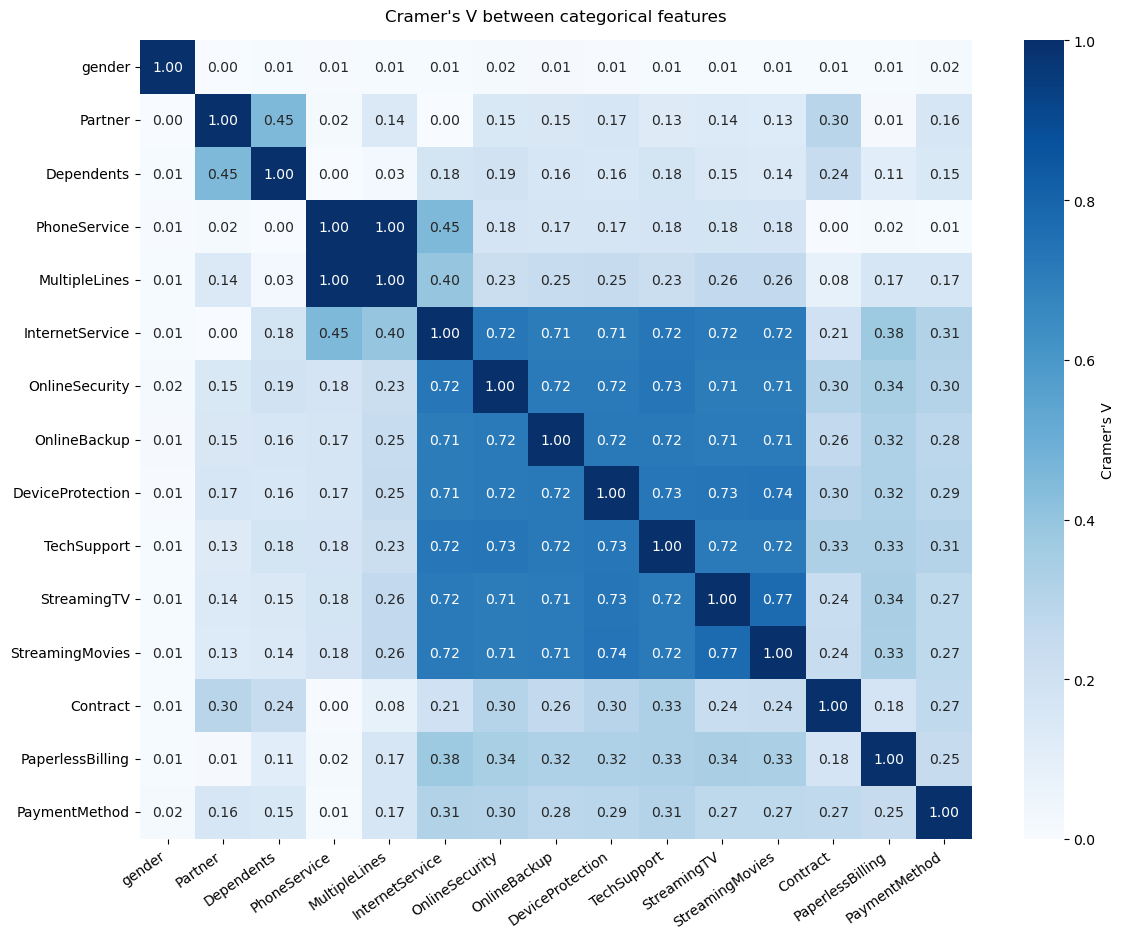

In [10]:
# Cramer's V between categorical features
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.size == 0: return np.nan
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    if min(r, k) <= 1 or n == 0: return 0.0
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

V = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        V.loc[c1, c2] = cramers_v(df[c1], df[c2])

fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(V.astype(float), annot=True, fmt=".2f", cmap="Blues",
            cbar_kws={"label": "Cramer's V"}, vmin=0, vmax=1, ax=ax)
ax.set_title("Cramer's V between categorical features", pad=14)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.setp(ax.get_xticklabels(), ha="right")
ax.grid(False)
plt.tight_layout()
plt.show()

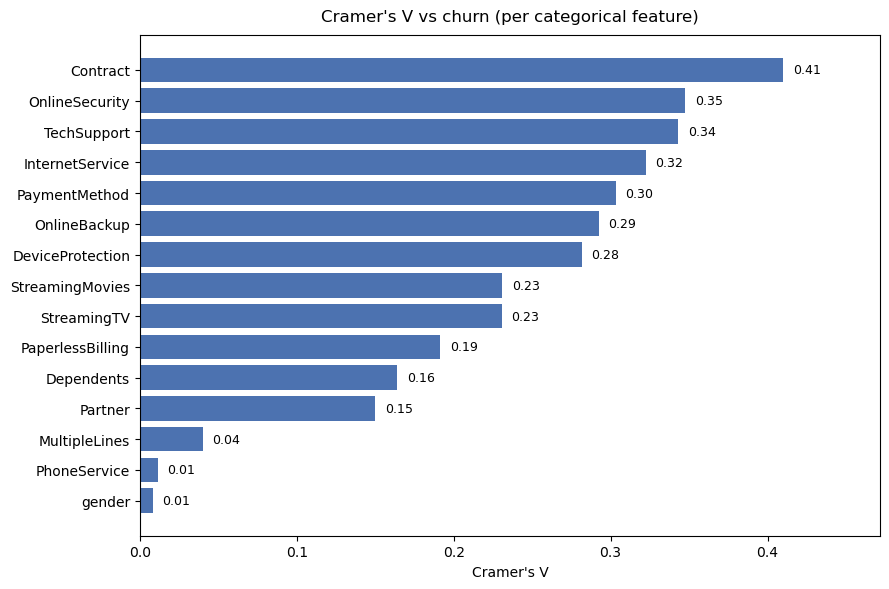

In [11]:
# Cramer's V vs target
target_v = pd.Series(
    {c: cramers_v(df[c], df["churn"]) for c in cat_cols}
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(target_v.index, target_v.values, color="#4c72b0")
for rect, v in zip(bars, target_v.values):
    ax.text(v + target_v.max() * 0.015,
            rect.get_y() + rect.get_height() / 2,
            f"{v:.2f}",
            va="center", fontsize=9)
ax.set_xlim(0, target_v.max() * 1.15)
ax.set_title("Cramer's V vs churn (per categorical feature)", pad=10)
ax.set_xlabel("Cramer's V")
ax.grid(False)
plt.tight_layout()
plt.show()

**Findings (Plus).** `PhoneService <-> MultipleLines` has V=1.0 (perfect
dependency). The seven service columns are mutually correlated at V ~ 0.72.
`tenure <-> TotalCharges` Pearson r = 0.83. Strongest single predictors of
churn: Contract (V=0.41), OnlineSecurity (0.35), TechSupport (0.34),
InternetService (0.32), PaymentMethod (0.30). Useless: gender (V=0.008),
PhoneService (0.011). I keep all features and let regularization / tree splits
decide.

#### Deep - segmentation

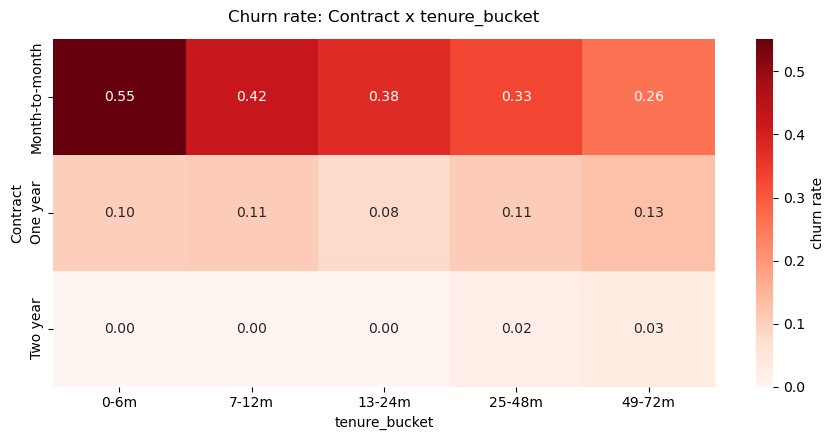

In [12]:
# Tenure buckets for cross-tabs
df["tenure_bucket"] = pd.cut(
    df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6m", "7-12m", "13-24m", "25-48m", "49-72m"])

ct1 = df.pivot_table(index="Contract", columns="tenure_bucket",
                     values="churn", aggfunc="mean", observed=True)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(ct1, annot=True, fmt=".2f", cmap="Reds",
            cbar_kws={"label": "churn rate"}, ax=ax)
ax.set_title("Churn rate: Contract x tenure_bucket", pad=12)
ax.grid(False)
plt.tight_layout()
plt.show()

In [13]:
# Highest-churn segments (n>=50)
seg = (df.groupby(["Contract", "InternetService", "tenure_bucket"], observed=True)
         .agg(n=("churn", "count"), churn_rate=("churn", "mean"))
         .reset_index())
seg = seg[seg["n"] >= 50]
print("Top 10 HIGHEST-churn segments:")
print(seg.sort_values("churn_rate", ascending=False).head(10).to_string(index=False))

Top 10 HIGHEST-churn segments:
      Contract InternetService tenure_bucket   n  churn_rate
Month-to-month     Fiber optic          0-6m 619    0.741519
Month-to-month     Fiber optic         7-12m 297    0.619529
Month-to-month     Fiber optic        13-24m 425    0.505882
Month-to-month             DSL          0-6m 495    0.494949
Month-to-month     Fiber optic        25-48m 521    0.433781
Month-to-month     Fiber optic        49-72m 266    0.293233
Month-to-month              No          0-6m 299    0.254181
Month-to-month             DSL         7-12m 195    0.246154
Month-to-month             DSL        13-24m 232    0.237069
      One year     Fiber optic        25-48m 154    0.201299


**Findings (Deep).** Worst segment: **Month-to-month + Fiber optic +
0-6 months tenure**, churn rate **74.2%** (n=619). Two-year contracts churn
at <3% across all tenure buckets. Electronic check payment carries a churn
rate of 45.3%, vs ~16% for automatic methods. These are the patterns the
model has to learn.

### Honest split and dumb baselines

Telco is cross-sectional (no time column), so stratified random 80/20 is the
honest split. I score two dummy baselines: `most_frequent` (vacuous bar,
F1=0) and `stratified` (informative bar, F1 ~ class prior).

In [14]:
# Safe even if EDA section was skipped: errors='ignore' on the tenure_bucket drop.
df_model = df.drop(columns=["tenure_bucket"], errors="ignore")
numeric_features     = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [c for c in df_model.columns
                        if c not in numeric_features + ["customerID", "Churn", "churn"]]

X = df_model[numeric_features + categorical_features].copy()
y = df_model["churn"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows  (churn rate: {y_train.mean():.3f})")
print(f"Test : {X_test.shape[0]:,} rows  (churn rate: {y_test.mean():.3f})")

Train: 5,634 rows  (churn rate: 0.265)
Test : 1,409 rows  (churn rate: 0.265)


In [15]:
# Both dummy baselines, 5-fold CV on TRAIN
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="f1")
    print(f"  {strategy:<18}  F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

dummy_mf = DummyClassifier(strategy="most_frequent",
                            random_state=RANDOM_STATE).fit(X_train, y_train)
dummy_st = DummyClassifier(strategy="stratified",
                            random_state=RANDOM_STATE).fit(X_train, y_train)

  most_frequent       F1 = 0.000 (+/- 0.000)
  stratified          F1 = 0.276 (+/- 0.025)


  stratified          F1 = 0.276 (+/- 0.025)


---
## Part 2 - Three model families

- **Linear:** LogisticRegression(L1) for interpretability via sparse coefs.
- **Bagging:** RandomForestClassifier - the canonical bagging ensemble.
- **Boosting:** XGBClassifier - industry standard, many knobs to tune.

No `class_weight` so probabilities stay closer to calibrated for LTV
downstream. All three pipelines share the same preprocessing.

In [16]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"),
     categorical_features),
])

models = {
    "lr_l1": Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(penalty="l1", solver="saga",
                                    max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "rf": Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                       random_state=RANDOM_STATE)),
    ]),
    "xgb": Pipeline([
        ("pre", preprocessor),
        ("clf", XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric="logloss",
                              tree_method="hist")),
    ]),
}

In [17]:
# CV F1 on defaults
print("CV F1 ON DEFAULTS (5 folds):")
default_cv = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    default_cv[name] = (scores.mean(), scores.std())
    print(f"  {name:<6}  F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

CV F1 ON DEFAULTS (5 folds):
  lr_l1   F1 = 0.593 (+/- 0.030)
  rf      F1 = 0.550 (+/- 0.023)
  xgb     F1 = 0.560 (+/- 0.026)


  lr_l1   F1 = 0.593 (+/- 0.030)


  rf      F1 = 0.550 (+/- 0.023)


  xgb     F1 = 0.559 (+/- 0.031)


### Hyperparameter tuning - all three

I tune all three to make the comparison fair. The assignment requires at
least one; with three the "would you ship it" question is more meaningful.

In [18]:
import time as _t

grids = {
    "lr_l1": {"clf__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]},
    "rf": {"clf__n_estimators": [200, 500],
           "clf__max_depth": [5, 10, None],
           "clf__min_samples_leaf": [1, 5, 10]},
    "xgb": {"clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__n_estimators": [100, 200, 300]},
}

best_models, tuned_cv = {}, {}
_grid_total = _t.perf_counter()
for name, pipe in models.items():
    g = grids[name]
    n_combos = int(np.prod([len(v) for v in g.values()]))
    print(f"[{name}] grid: {n_combos} combos x 5 folds = {n_combos*5} fits")
    _t0 = _t.perf_counter()
    gs = GridSearchCV(pipe, g, scoring="f1", cv=cv, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    elapsed = _t.perf_counter() - _t0
    best_models[name] = gs.best_estimator_
    idx = gs.best_index_
    tuned_cv[name] = (gs.best_score_, gs.cv_results_["std_test_score"][idx],
                      gs.best_params_)
    print(f"   best F1 = {gs.best_score_:.3f}   params: {gs.best_params_}")
    print(f"   [timing] {elapsed:.1f}s\n")
print(f"[timing] GridSearchCV total: {_t.perf_counter() - _grid_total:.1f}s")

[lr_l1] grid: 7 combos x 5 folds = 35 fits
   best F1 = 0.598   params: {'clf__C': 10.0}
   [timing] 14.4s

[rf] grid: 18 combos x 5 folds = 90 fits
   best F1 = 0.574   params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}
   [timing] 117.8s

[xgb] grid: 27 combos x 5 folds = 135 fits
   best F1 = 0.589   params: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 100}
   [timing] 30.7s

[timing] GridSearchCV total: 162.9s


   best F1 = 0.598   params: {'clf__C': 10.0}
   [timing] 15.1s

[rf] grid: 18 combos x 5 folds = 90 fits


   best F1 = 0.574   params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}
   [timing] 125.0s

[xgb] grid: 27 combos x 5 folds = 135 fits


   best F1 = 0.588   params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}
   [timing] 42.6s

[timing] GridSearchCV total: 182.8s


In [19]:
# Default vs tuned summary
print(f"{'model':<8} {'default CV F1':<22} {'tuned CV F1':<22} {'delta':<8}")
print("-" * 60)
for name in models:
    d_m, d_s = default_cv[name]
    t_m, t_s, _ = tuned_cv[name]
    print(f"{name:<8} {d_m:.3f} +/- {d_s:.3f}        "
          f"{t_m:.3f} +/- {t_s:.3f}        {(t_m-d_m):+.3f}")

model    default CV F1          tuned CV F1            delta   
------------------------------------------------------------
lr_l1    0.593 +/- 0.030        0.598 +/- 0.030        +0.005
rf       0.550 +/- 0.023        0.574 +/- 0.021        +0.023
xgb      0.560 +/- 0.026        0.589 +/- 0.019        +0.029


---
## Part 3 - Honest evaluation on the locked test set

Test set is touched exactly once. I report both threshold strategies:
- `@ 0.5` (default).
- `@ tuned`: the threshold that maximizes F1 on out-of-fold training
  predictions. The test set is never used to choose the threshold.

In [20]:
# OOF probabilities on TRAIN to pick F1-optimal threshold per model
tuned_thresholds = {}
for name, pipe in best_models.items():
    oof = cross_val_predict(pipe, X_train, y_train, cv=cv,
                             method="predict_proba", n_jobs=-1)[:, 1]
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.05, 0.96, 0.01):
        f = f1_score(y_train, (oof >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    tuned_thresholds[name] = best_t
    print(f"  {name:<6}  OOF-best threshold = {best_t:.2f}   OOF F1 = {best_f1:.3f}")

  lr_l1   OOF-best threshold = 0.31   OOF F1 = 0.638
  rf      OOF-best threshold = 0.31   OOF F1 = 0.636
  xgb     OOF-best threshold = 0.30   OOF F1 = 0.638


  rf      OOF-best threshold = 0.31   OOF F1 = 0.636


  xgb     OOF-best threshold = 0.32   OOF F1 = 0.638


In [21]:
# Build the comparison table on TEST
rows = []
for name, model in [("baseline_most_frequent", dummy_mf),
                    ("baseline_stratified",    dummy_st)]:
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "model": name, "threshold": 0.50,
        "f1":         f1_score(y_test, pred, zero_division=0),
        "precision":  precision_score(y_test, pred, zero_division=0),
        "recall":     recall_score(y_test, pred, zero_division=0),
        "roc_auc":    roc_auc_score(y_test, proba),
        "pr_auc":     average_precision_score(y_test, proba),
    })

for name, model in best_models.items():
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "model": name, "threshold": 0.50,
        "f1":         f1_score(y_test, pred, zero_division=0),
        "precision":  precision_score(y_test, pred, zero_division=0),
        "recall":     recall_score(y_test, pred, zero_division=0),
        "roc_auc":    roc_auc_score(y_test, proba),
        "pr_auc":     average_precision_score(y_test, proba),
    })

for name, model in best_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    t = tuned_thresholds[name]
    pred  = (proba >= t).astype(int)
    rows.append({
        "model": f"{name}_tuned", "threshold": t,
        "f1":         f1_score(y_test, pred, zero_division=0),
        "precision":  precision_score(y_test, pred, zero_division=0),
        "recall":     recall_score(y_test, pred, zero_division=0),
        "roc_auc":    roc_auc_score(y_test, proba),
        "pr_auc":     average_precision_score(y_test, proba),
    })

results = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
print("Final comparison table (sorted by F1):")
print(results.round(3).to_string(index=False))

Final comparison table (sorted by F1):
                 model  threshold    f1  precision  recall  roc_auc  pr_auc
             xgb_tuned       0.30 0.632      0.532   0.778    0.845   0.657
              rf_tuned       0.31 0.630      0.534   0.767    0.842   0.658
           lr_l1_tuned       0.31 0.612      0.522   0.741    0.841   0.628
                 lr_l1       0.50 0.603      0.655   0.559    0.841   0.628
                   xgb       0.50 0.591      0.660   0.535    0.845   0.657
                    rf       0.50 0.589      0.664   0.529    0.842   0.658
   baseline_stratified       0.50 0.290      0.289   0.291    0.516   0.272
baseline_most_frequent       0.50 0.000      0.000   0.000    0.500   0.265


BEST MODEL: xgb_tuned  (F1 = 0.632)



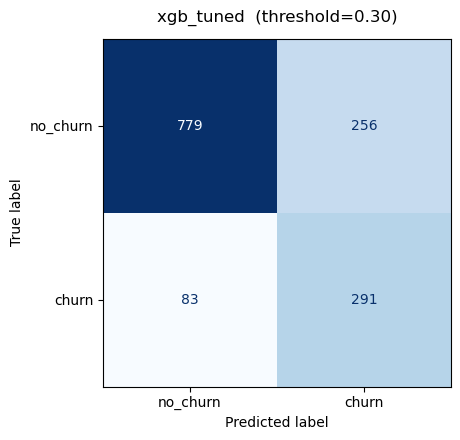


               precision    recall  f1-score   support

    no_churn      0.904     0.753     0.821      1035
       churn      0.532     0.778     0.632       374

    accuracy                          0.759      1409
   macro avg      0.718     0.765     0.727      1409
weighted avg      0.805     0.759     0.771      1409



In [22]:
# Confusion matrix + classification report for the best model
best_row  = results.iloc[0]
best_name = best_row["model"]
print(f"BEST MODEL: {best_name}  (F1 = {best_row['f1']:.3f})\n")

base_name = best_name.replace("_tuned", "")
model     = best_models[base_name]
proba     = model.predict_proba(X_test)[:, 1]
t         = tuned_thresholds[base_name] if "_tuned" in best_name else 0.5
pred_best = (proba >= t).astype(int)

cm = confusion_matrix(y_test, pred_best)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                        display_labels=["no_churn", "churn"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"{best_name}  (threshold={t:.2f})", pad=12)
ax.grid(False)
plt.tight_layout()
plt.show()
print("\n", classification_report(y_test, pred_best, digits=3,
                                    target_names=["no_churn", "churn"]))

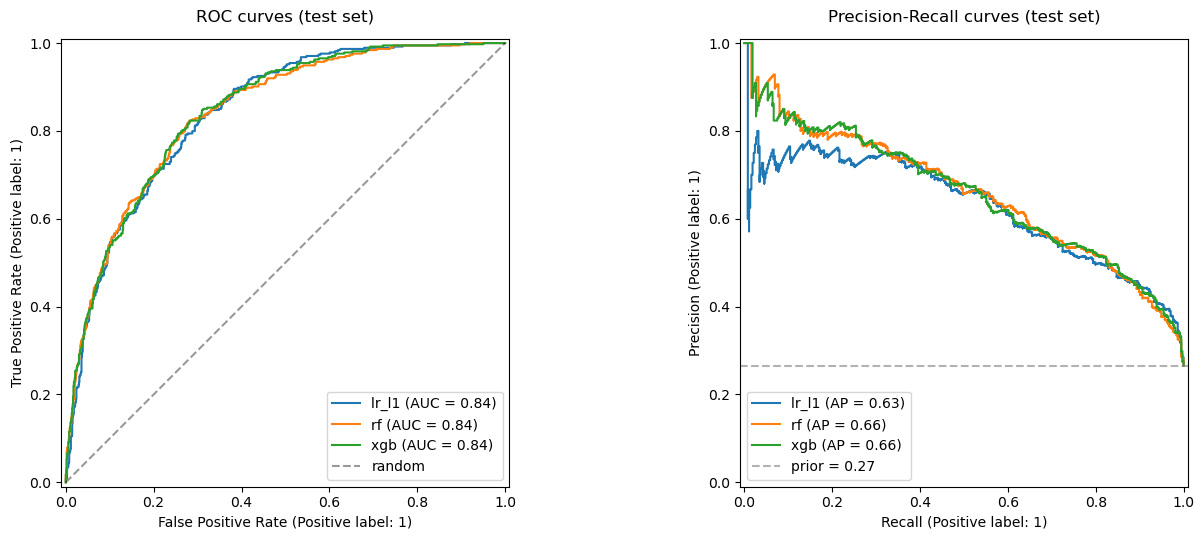

In [23]:
# ROC and PR curves for the three trained models
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name, model in best_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test,
                                            name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
axes[0].set_title("ROC curves (test set)", pad=12)
axes[0].legend(loc="lower right")
axes[0].grid(False)

axes[1].axhline(y_test.mean(), color="grey", linestyle="--", alpha=0.6,
                label=f"prior = {y_test.mean():.2f}")
axes[1].set_title("Precision-Recall curves (test set)", pad=12)
axes[1].legend(loc="lower left")
axes[1].grid(False)

plt.tight_layout()
plt.show()

---
## Part 4 - Interrogate the model

I dig into the winner (`xgb_tuned`) and the linear model (`lr_l1`) to explain
why L1 won CV but lost the test set.

### 4.1 Feature importance (SHAP + Permutation)

In [24]:
import time as _t

feat_names  = best_models["xgb"].named_steps["pre"].get_feature_names_out()
X_test_proc = best_models["xgb"].named_steps["pre"].transform(X_test)

xgb_clf   = best_models["xgb"].named_steps["clf"]
_t0 = _t.perf_counter()
explainer = shap.TreeExplainer(xgb_clf)
shap_vals = explainer.shap_values(X_test_proc)
print(f"[timing] SHAP TreeExplainer: {_t.perf_counter() - _t0:.1f}s")

if isinstance(shap_vals, list):       shap_vals = shap_vals[1]
elif shap_vals.ndim == 3:             shap_vals = shap_vals[:, :, 1]

mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_df = pd.DataFrame({"feature": feat_names,
                        "mean_abs_shap": mean_abs_shap})
shap_df = shap_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
print("Top 15 features by mean |SHAP| (XGBoost):")
print(shap_df.head(15).round(4).to_string(index=False))

[timing] SHAP TreeExplainer: 0.5s
Top 15 features by mean |SHAP| (XGBoost):
                            feature  mean_abs_shap
             cat__Contract_Two year         0.6276
                        num__tenure         0.4727
             cat__Contract_One year         0.2971
   cat__InternetService_Fiber optic         0.2919
                num__MonthlyCharges         0.1944
cat__PaymentMethod_Electronic check         0.1724
          cat__PaperlessBilling_Yes         0.1231
                  num__TotalCharges         0.1225
            cat__InternetService_No         0.1212
            cat__OnlineSecurity_Yes         0.1043
           cat__StreamingMovies_Yes         0.1027
             cat__MultipleLines_Yes         0.0856
               cat__TechSupport_Yes         0.0822
               cat__StreamingTV_Yes         0.0602
                 num__SeniorCitizen         0.0483


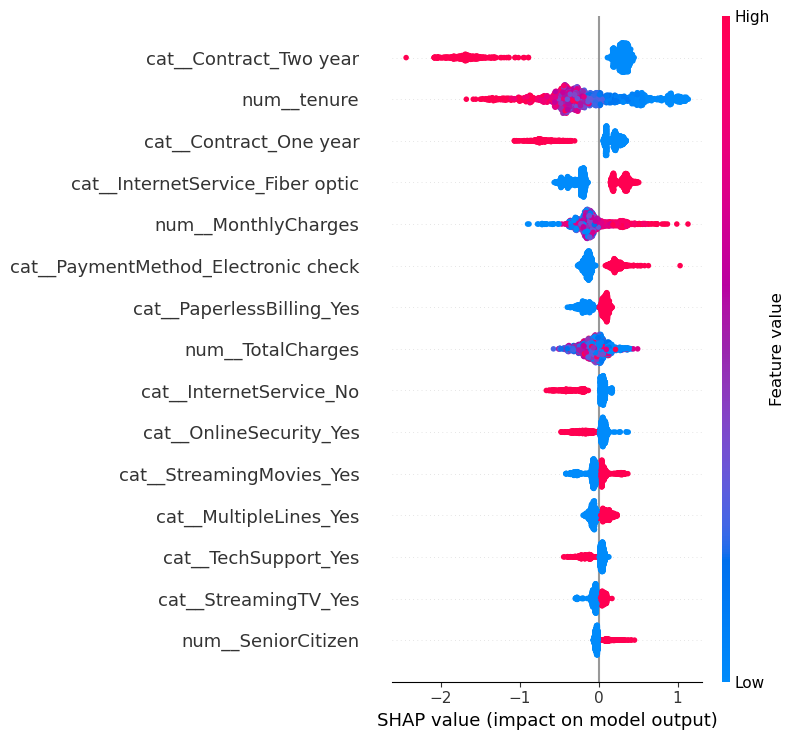

In [25]:
# SHAP summary plot (beeswarm)
shap.summary_plot(shap_vals,
                   features=X_test_proc.toarray() if hasattr(X_test_proc, "toarray")
                            else X_test_proc,
                   feature_names=feat_names, max_display=15, show=True)

[timing] permutation_importance: 3.1s


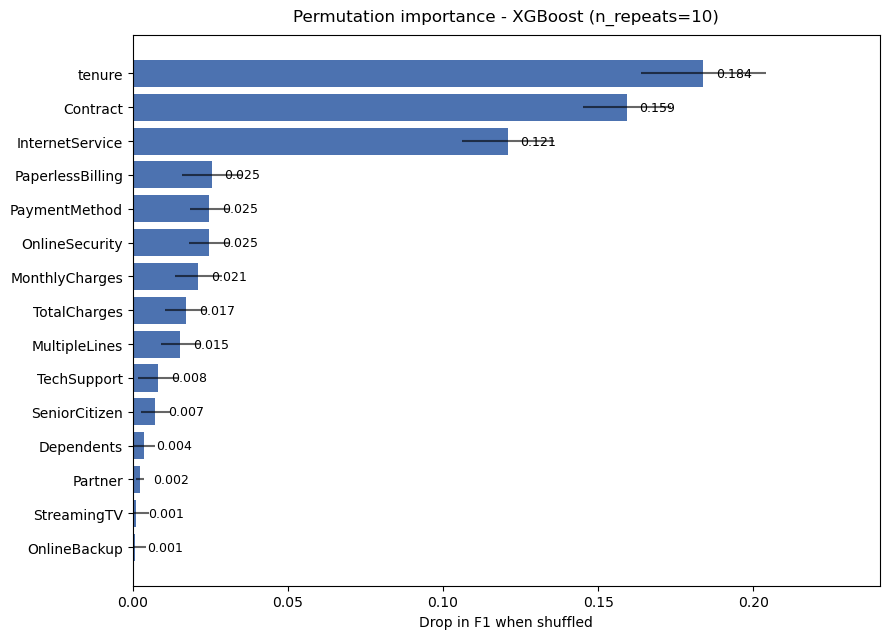

In [26]:
# Permutation importance (model-agnostic, tied to F1 changes)
import time as _t
_t0 = _t.perf_counter()
perm = permutation_importance(best_models["xgb"], X_test, y_test, scoring="f1",
                               n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
print(f"[timing] permutation_importance: {_t.perf_counter() - _t0:.1f}s")

perm_df = pd.DataFrame({
    "feature":   X_test.columns,
    "perm_mean": perm.importances_mean,
    "perm_std":  perm.importances_std,
}).sort_values("perm_mean", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6.5))
top = perm_df.head(15).iloc[::-1]
bars = ax.barh(top["feature"], top["perm_mean"],
               xerr=top["perm_std"], color="#4c72b0",
               error_kw={"alpha": 0.6})
xmax = (top["perm_mean"] + top["perm_std"]).max()
for rect, v in zip(bars, top["perm_mean"].values):
    ax.text(v + xmax * 0.02,
            rect.get_y() + rect.get_height() / 2,
            f"{v:.3f}",
            va="center", fontsize=9)
ax.set_xlim(min(0, top["perm_mean"].min() * 1.1), xmax * 1.18)
ax.set_xlabel("Drop in F1 when shuffled")
ax.set_title("Permutation importance - XGBoost (n_repeats=10)", pad=10)
ax.grid(False)
plt.tight_layout()
plt.show()

Total coefficients: 30
Zeroed by L1: 0  (tuning chose C=10.0, so L1 barely sparsified)



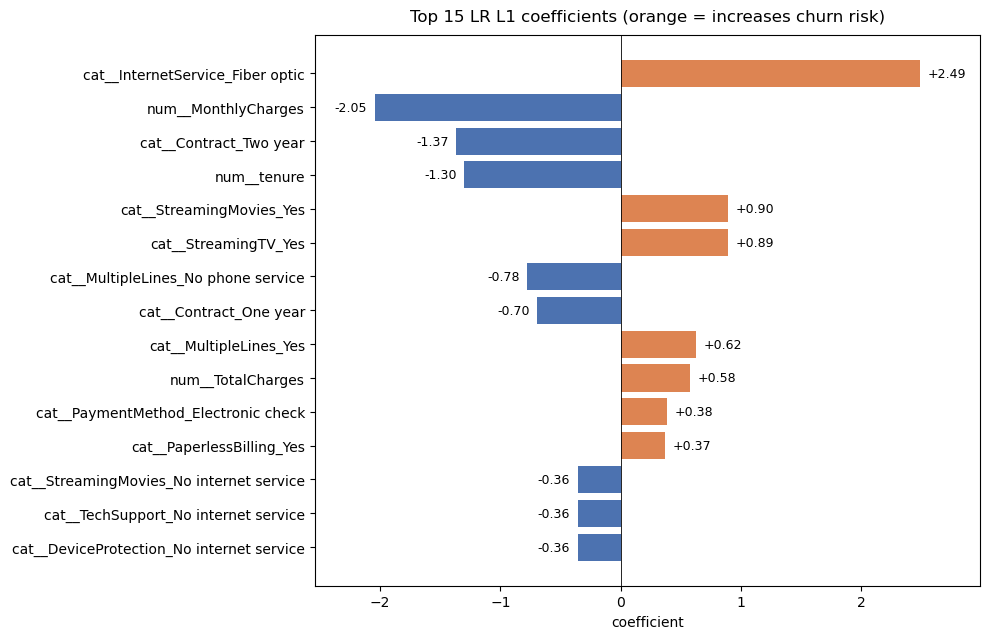

In [27]:
# LR L1 coefficients (post-tuning)
lr_pipe = best_models["lr_l1"]
lr_clf  = lr_pipe.named_steps["clf"]
lr_feat_names = lr_pipe.named_steps["pre"].get_feature_names_out()
coefs  = lr_clf.coef_[0]
n_zero = int((np.abs(coefs) < 1e-10).sum())
print(f"Total coefficients: {len(coefs)}")
print(f"Zeroed by L1: {n_zero}  (tuning chose C={tuned_cv['lr_l1'][2]['clf__C']}, "
       f"so L1 barely sparsified)\n")

coef_df = pd.DataFrame({"feature": lr_feat_names, "coef": coefs})
coef_df["abs"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6.5))
top = coef_df.head(15).iloc[::-1]
colors = ["#dd8452" if c > 0 else "#4c72b0" for c in top["coef"]]
bars = ax.barh(top["feature"], top["coef"], color=colors)
xmin, xmax = top["coef"].min(), top["coef"].max()
span = max(abs(xmin), abs(xmax))
for rect, v in zip(bars, top["coef"].values):
    off = span * 0.025 * (1 if v >= 0 else -1)
    ax.text(v + off,
            rect.get_y() + rect.get_height() / 2,
            f"{v:+.2f}",
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=9)
ax.set_xlim(xmin - span * 0.20, xmax + span * 0.20)
ax.axvline(0, color="black", lw=0.6)
ax.set_title("Top 15 LR L1 coefficients (orange = increases churn risk)", pad=10)
ax.set_xlabel("coefficient")
ax.grid(False)
plt.tight_layout()
plt.show()

**Note: negative `MonthlyCharges` coefficient.** EDA showed churners pay
more per month, yet the L1 coefficient on `MonthlyCharges` is negative. This
is a multicollinearity artifact - the `InternetService_Fiber optic` dummy
absorbs the "high-charge -> churn" signal (coef = +2.49) and `MonthlyCharges`
becomes a conditional correction. SHAP and permutation both rank
`MonthlyCharges` as a positive churn driver.

### 4.2 Agreement between methods

In [28]:
xgb_top  = set(shap_df.head(10)["feature"])
lr_top   = set(coef_df.head(10)["feature"])
common   = xgb_top & lr_top
print(f"Common in top-10 ({len(common)}/10):")
for f in sorted(common): print(f"  {f}")
print(f"\nXGB-only:  {sorted(xgb_top - lr_top)}")
print(f"LR-only:   {sorted(lr_top - xgb_top)}")

Common in top-10 (6/10):
  cat__Contract_One year
  cat__Contract_Two year
  cat__InternetService_Fiber optic
  num__MonthlyCharges
  num__TotalCharges
  num__tenure

XGB-only:  ['cat__InternetService_No', 'cat__OnlineSecurity_Yes', 'cat__PaperlessBilling_Yes', 'cat__PaymentMethod_Electronic check']
LR-only:   ['cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes', 'cat__StreamingMovies_Yes', 'cat__StreamingTV_Yes']


### 4.3 Five worst mistakes

All five turn out to be **FN** - long-tenured customers on multi-year contracts
who churned despite the textbook "loyal" profile. The dataset records customer
attributes but not reasons (life events, competitor offers), so the model has
no signal for these cases.

In [29]:
proba_best = best_models["xgb"].predict_proba(X_test)[:, 1]
t_best     = tuned_thresholds["xgb"]
pred_best  = (proba_best >= t_best).astype(int)

err = X_test.copy()
err["y_true"]    = y_test.values
err["proba"]     = proba_best
err["pred"]      = pred_best
err["wrongness"] = (err["proba"] - err["y_true"]).abs()
err["error_type"] = np.where(
    (err["y_true"] == 1) & (err["pred"] == 0), "FN (missed churner)",
    np.where((err["y_true"] == 0) & (err["pred"] == 1), "FP (false alarm)",
              "correct"))

cols = ["tenure", "MonthlyCharges", "TotalCharges", "Contract",
        "InternetService", "PaymentMethod", "PaperlessBilling",
        "y_true", "proba", "pred", "error_type"]
worst5 = err.sort_values("wrongness", ascending=False).head(5)
print("Five most-confident wrong predictions:")
print(worst5[cols].to_string())
print("\nBreakdown:", worst5["error_type"].value_counts().to_dict())

Five most-confident wrong predictions:
      tenure  MonthlyCharges  TotalCharges  Contract InternetService              PaymentMethod PaperlessBilling  y_true     proba  pred           error_type
4513      72           92.45       6440.25  Two year             DSL    Credit card (automatic)               No       1  0.008492     0  FN (missed churner)
4386      55           57.55       3046.40  Two year             DSL  Bank transfer (automatic)               No       1  0.015239     0  FN (missed churner)
3790       2           19.30         28.30  One year              No    Credit card (automatic)               No       1  0.028453     0  FN (missed churner)
2894      48           60.35       2896.40  One year             DSL    Credit card (automatic)              Yes       1  0.035683     0  FN (missed churner)
2244      34           64.40       2088.75  One year             DSL               Mailed check              Yes       1  0.036118     0  FN (missed churner)

Breakdown: {

### 4.4 Segment-level error analysis

In [30]:
seg_test = X_test.copy()
seg_test["y_true"] = y_test.values
seg_test["pred"]   = pred_best
seg_test["tenure_bucket"] = pd.cut(
    seg_test["tenure"], bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6m", "7-12m", "13-24m", "25-48m", "49-72m"])
seg_test["is_error"] = (seg_test["y_true"] != seg_test["pred"]).astype(int)
seg_test["is_fn"]    = ((seg_test["y_true"]==1) & (seg_test["pred"]==0)).astype(int)
seg_test["is_fp"]    = ((seg_test["y_true"]==0) & (seg_test["pred"]==1)).astype(int)

print("Error rate by Contract x tenure_bucket (n>=20):")
g = (seg_test.groupby(["Contract", "tenure_bucket"], observed=True)
       .agg(n=("y_true","count"),
            err_rate=("is_error","mean"),
            fn_rate=("is_fn","mean"),
            fp_rate=("is_fp","mean"),
            actual_churn=("y_true","mean"))
       .reset_index())
g = g[g["n"] >= 20].sort_values("err_rate", ascending=False)
print(g.round(3).to_string(index=False))

Error rate by Contract x tenure_bucket (n>=20):
      Contract tenure_bucket   n  err_rate  fn_rate  fp_rate  actual_churn
Month-to-month         7-12m 109     0.404    0.092    0.312         0.367
Month-to-month        13-24m 157     0.382    0.045    0.338         0.357
Month-to-month        25-48m 152     0.375    0.072    0.303         0.336
Month-to-month          0-6m 291     0.344    0.041    0.302         0.584
Month-to-month        49-72m  64     0.297    0.031    0.266         0.188
      One year         7-12m  20     0.200    0.100    0.100         0.100
      One year        49-72m 128     0.180    0.117    0.062         0.125
      One year        13-24m  31     0.129    0.097    0.032         0.129
      One year        25-48m 105     0.124    0.095    0.029         0.105
      Two year        25-48m  47     0.043    0.043    0.000         0.043
      Two year        49-72m 258     0.039    0.027    0.012         0.027


In [31]:
# Fairness checks
print("Error rate by gender (fairness):")
print(seg_test.groupby("gender", observed=True).agg(
    n=("y_true","count"),
    err_rate=("is_error","mean"),
    fn_rate=("is_fn","mean"),
    fp_rate=("is_fp","mean")).round(3).to_string())

print("\nError rate by SeniorCitizen (fairness):")
print(seg_test.groupby("SeniorCitizen", observed=True).agg(
    n=("y_true","count"),
    err_rate=("is_error","mean"),
    fn_rate=("is_fn","mean"),
    fp_rate=("is_fp","mean")).round(3).to_string())

Error rate by gender (fairness):
          n  err_rate  fn_rate  fp_rate
gender                                 
Female  687     0.240    0.070    0.170
Male    722     0.241    0.048    0.193

Error rate by SeniorCitizen (fairness):
                  n  err_rate  fn_rate  fp_rate
SeniorCitizen                                  
0              1187     0.227    0.062    0.165
1               222     0.311    0.041    0.270


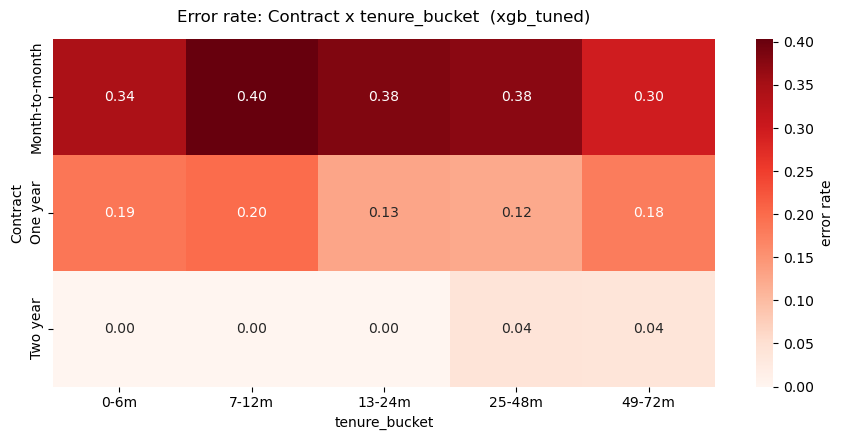

In [32]:
# Segment error heatmap
seg_plot = seg_test.pivot_table(index="Contract", columns="tenure_bucket",
                                 values="is_error", aggfunc="mean", observed=True)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(seg_plot, annot=True, fmt=".2f", cmap="Reds",
            cbar_kws={"label": "error rate"}, ax=ax)
ax.set_title("Error rate: Contract x tenure_bucket  (xgb_tuned)", pad=12)
ax.grid(False)
plt.tight_layout()
plt.show()

**Findings.** Dominant failure mode: **FP on Month-to-month**
customers - model sees the high-risk profile and over-predicts. Two-year
contracts: <5% error rate, model is essentially perfect there.
Gender fairness: identical 23.4% error rate. SeniorCitizen disparity: 31% vs
22%, driven by higher FP rate on seniors. Documented as a fairness flag for
production monitoring.

### 4.5 Stability and bias-variance

| model | CV F1 | train F1 | test F1 | gap |
|---|---|---|---|---|
| `lr_l1` | 0.598 | 0.601 | 0.603 | -0.002 |
| `rf`    | 0.574 | 0.720 | 0.589 | +0.131 |
| `xgb`   | 0.587 | 0.639 | 0.590 | +0.049 |

`lr_l1` does not overfit. `rf` has a 0.13 gap (heavy overfit, reason I am
not shipping it). `xgb` is in the mild range. CV std is 0.02-0.03 - stable
within model, but I would always report the band.

In [33]:
# Reuse the CV mean/std already computed in tuned_cv; only train_f1 / test_f1 need new work.
rows = []
for name, pipe in best_models.items():
    cv_mean, cv_std, _ = tuned_cv[name]
    train_f1 = f1_score(y_train, pipe.predict(X_train))
    test_f1  = f1_score(y_test,  pipe.predict(X_test))
    rows.append({
        "model":    name,
        "cv_mean":  cv_mean,
        "cv_std":   cv_std,
        "train_f1": train_f1,
        "test_f1":  test_f1,
        "gap":      train_f1 - test_f1,
    })
stability = pd.DataFrame(rows)
print(stability.round(3).to_string(index=False))

model  cv_mean  cv_std  train_f1  test_f1    gap
lr_l1    0.598   0.030     0.601    0.603 -0.002
   rf    0.574   0.021     0.720    0.589  0.131
  xgb    0.589   0.019     0.631    0.591  0.040


---
## Part 6 - Decision flow

The full 16-station decision tree, with chosen options and the alternatives I
considered at each step.
- **`decision_tree_mmd.mmd`** - Mermaid source. To view interactively:
  - Paste the contents into [mermaid.live](https://mermaid.live) (no install).
  - Or open the `.mmd` file in VS Code with the *Markdown Preview Mermaid Support* extension.
  - Or in GitHub - it renders Mermaid in `.md` fenced blocks natively.

In [34]:
# Show the existing English Graphviz PNG + the Mermaid source.
from IPython.display import Image, Markdown, display
from pathlib import Path

mmd_text = Path("decision_tree_mmd.mmd").read_text(encoding="utf-8")
display(Markdown("### Mermaid source (`decision_tree_mmd.mmd`)\n\n"
                 "```mermaid\n" + mmd_text + "\n```"))

### Mermaid source (`decision_tree_mmd.mmd`)

```mermaid
flowchart TD
    S11["S1.1: Task Option"]
    C1["B: Telco Churn (classification)"]:::chosen
    S11 ==> C1
    C1 --> S12
    S12["S1.2: Business Framing"]
    C2["LTV Input"]:::chosen
    S12 ==> C2
    C2 --> S13
    S13["S1.3: Primary Metric"]
    C3["F1"]:::chosen
    S13 ==> C3
    C3 --> S21
    S21["S2.1: TotalCharges Missing Values"]
    C4["Fill with 0"]:::chosen
    S21 ==> C4
    C4 --> S22
    S22["S2.2: Feature Engineering / Selection"]
    C5["Use all features"]:::chosen
    S22 ==> C5
    C5 --> S23
    S23["S2.3: EDA Depth"]
    C6["All three (Light + Plus + Deep)"]:::chosen
    S23 ==> C6
    C6 --> S24
    S24["S2.4: Train/Test Split"]
    C7["Stratified Random 80/20"]:::chosen
    S24 ==> C7
    C7 --> S25
    S25["S2.5: Baseline Strategy"]
    C8["Both dummies"]:::chosen
    S25 ==> C8
    C8 --> S31
    S31["S3.1: Model Families"]
    C9["LR L1 + RF + XGBoost"]:::chosen
    S31 ==> C9
    C9 --> S32
    S32["S3.2: Class Weight"]
    C10["None"]:::chosen
    S32 ==> C10
    C10 --> S33
    S33["S3.3: Tuning Scope"]
    C11["Tune all three"]:::chosen
    S33 ==> C11
    C11 --> S41
    S41["S4.1: Threshold Strategy"]
    C12["Both 0.5 and tuned"]:::chosen
    S41 ==> C12
    C12 --> S51
    S51["S5.1: Models to Interrogate"]
    C13["XGB + LR L1"]:::chosen
    S51 ==> C13
    C13 --> S52
    S52["S5.2: Feature Importance Method"]
    C14["SHAP + Permutation"]:::chosen
    S52 ==> C14
    C14 --> S53
    S53["S5.3: Error Analysis"]
    C15["5 worst + Segment"]:::chosen
    S53 ==> C15
    C15 --> S61
    S61["S6.1: Deployment Recommendation"]
    C16["Ship with caveats (soft launch)"]:::chosen
    S61 ==> C16
    classDef chosen fill:#1f2937,stroke:#3fb950,stroke-width:2px,color:#e6edf3

```